# 3.4 Basic — Traditional Media Models

Traditional media features only (newspaper volume + sentiment).

**Pipeline:** Gold → Model outputs  
**Input:** `Data/3_Gold/basetable_preprocessed.csv`  
**Output:** Model metrics and visualisations

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Load Data & Compute Target](#1-load-data-compute-target)
- [2. Train/Val/Test Split](#2-trainvaltest-split)
- [3. CV Folds](#3-cv-folds)
- [4. Helper Functions](#4-helper-functions)
- [5. Model 1 — Ridge Regression](#5-model-1-ridge-regression)
- [6. Model 2 — Random Forest Regressor](#6-model-2-random-forest-regressor)
- [7. Model 3 — Support Vector Regression (tuned kernel)](#7-model-3-support-vector-regression-tuned-kernel)
- [8. Model 4 — XGBoost Regressor](#8-model-4-xgboost-regressor)
- [9. Naive Baseline — Always Predict Zero](#9-naive-baseline-always-predict-zero)
- [10. Model Comparison](#10-model-comparison)


## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from Functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from Functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval, tune_hyperparams,
)
from house_style import *
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

TRAD_COLS = [
    # ── Newspaper volume ───────────────────────────────────────────────────────
    "news_election_count",
    "news_attention_asymmetry_7d",
    "news_vader_leaning_gap",
    # ── VADER sentiment by leaning ─────────────────────────────────────────────
    "vader_compound_mean_dem",
    "vader_compound_std_dem",
    "vader_neg_share_dem",
    # ── NRC emotions — centrist outlets ───────────────────────────────────────
    "nrc_fear_cen",
    "nrc_anger_cen",
    "nrc_anticipation_cen",
    "nrc_surprise_cen",
    "nrc_sadness_cen",
    "nrc_joy_cen",
    # ── NRC emotions — democratic-leaning outlets ─────────────────────────────
    "nrc_anticipation_dem",
    "nrc_surprise_dem",
    "nrc_sadness_dem",
    "nrc_disgust_dem",
    "nrc_joy_dem",
    # ── NRC emotions — republican-leaning outlets ─────────────────────────────
    "nrc_anticipation_rep",
    "nrc_sadness_rep",
]

MODEL_COLORS = {
    "Naive (zero)"    : NEUTRAL,
    "Ridge Regression" : PALETTE[0],
    "Random Forest"   : PALETTE[1],
    "SVM"             : PALETTE[4],
    "XGBoost"         : PALETTE[2],
}

print("Imports OK")

Imports OK


## 1. Load Data & Compute Target

We load `basetable_preprocessed.csv` and keep only traditional media features.
Target: daily first-difference of Polymarket Trump probability.

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

missing = [c for c in TRAD_COLS if c not in df_raw.columns]
assert not missing, f"Missing traditional-media columns: {missing} — re-run preprocessing.ipynb"
assert "polymarket_trump_prob_lag1" in df_raw.columns, \
    "polymarket_trump_prob_lag1 not found — re-run preprocessing.ipynb"

df = df_raw[["date"] + TRAD_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]
df = df.dropna().reset_index(drop=True)

print(f"Rows          : {len(df)}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features ({len(TRAD_COLS)}): {len(TRAD_COLS)} traditional-media columns")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows          : 123
Date range    : 2024-07-05 -> 2024-11-04
Features (19): 19 traditional-media columns

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 2. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** as the held-out test set.
The remaining rows form the train+val (TV) set used for CV and final training.

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[TRAD_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[TRAD_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 3. CV Folds

**3 expanding-window folds** on the TV set with a 1-day gap. `validate_no_leakage` confirms no future data bleeds into training.

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 4. Helper Functions

All helpers are imported from `Functions.evaluation_metrics`:
`tune_hyperparams`, `cv_evaluate`, `final_eval`, `compute_metrics`, `directional_accuracy`.

## 5. Model 1 — Ridge Regression

Ridge adds an L2 penalty to OLS: `β̂ = argmin ||y − Xβ||² + α||β||²`.
With many correlated NRC emotion features, L2 regularisation prevents coefficient blow-up. We tune `alpha` over a log-scale grid.

In [5]:
def make_ridge(alpha):
    return Ridge(alpha=alpha)

ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

print("=== Ridge Regression — Hyperparameter Tuning ===")
ridge_best, ridge_tune_df = tune_hyperparams(
    make_ridge, ridge_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {ridge_best}")
print(f"\n  All configurations (sorted by CV MAE):")
print(ridge_tune_df.to_string(index=False))

lr_factory = lambda: make_ridge(**ridge_best)
print("\n=== Ridge Regression — CV (best params) ===")
lr_cv = cv_evaluate(lr_factory, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

=== Ridge Regression — Hyperparameter Tuning ===
  Best params : {'alpha': 1000.0}

  All configurations (sorted by CV MAE):
   alpha   cv_mae  cv_mae_std
1000.000 0.010328    0.001884
 500.000 0.010360    0.001925
 100.000 0.010977    0.001728
  10.000 0.013542    0.000830
   1.000 0.016835    0.002070
   0.100 0.019358    0.005280
   0.010 0.021381    0.008104
   0.001 0.021793    0.008683

=== Ridge Regression — CV (best params) ===
  Fold 1: MAE=0.0115  RMSE=0.0151  DA=0.556  R2=-0.0069
  Fold 2: MAE=0.0077  RMSE=0.0098  DA=0.481  R2=0.0049
  Fold 3: MAE=0.0118  RMSE=0.0162  DA=0.333  R2=-0.2923
  -- Mean --  MAE=0.0103  RMSE=0.0137  DA=0.457  R2=-0.0981


,MAE,RMSE,Dir. Accuracy,R2
1,0.0115,0.0151,0.5556,-0.0069
2,0.0077,0.0098,0.4815,0.0049
3,0.0118,0.0162,0.3333,-0.2923
Mean,0.0103,0.0137,0.4568,-0.0981
Std,0.0023,0.0034,0.1132,0.1683


In [6]:
lr_model, lr_pred, lr_test = final_eval(
    lr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("Ridge Regression — Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression — Test set:
  MAE: 0.0160
  RMSE: 0.0208
  Dir. Accuracy: 0.5000
  R2: -0.0645


## 6. Model 2 — Random Forest Regressor

Random Forest builds an ensemble of decorrelated trees. We tune `max_depth` and `min_samples_leaf`.

In [7]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'min_samples_leaf': 1}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 1 0.011294    0.002430
         3                 1 0.011422    0.002688
         2                 2 0.011582    0.002650
         2                 3 0.011721    0.002619
         3                 2 0.011727    0.002869

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0133  RMSE=0.0176  DA=0.519  R2=-0.3596
  Fold 2: MAE=0.0079  RMSE=0.0095  DA=0.481  R2=0.0738
  Fold 3: MAE=0.0127  RMSE=0.0172  DA=0.407  R2=-0.4448
  -- Mean --  MAE=0.0113  RMSE=0.0147  DA=0.469  R2=-0.2436


,MAE,RMSE,Dir. Accuracy,R2
1,0.0133,0.0176,0.5185,-0.3596
2,0.0079,0.0095,0.4815,0.0738
3,0.0127,0.0172,0.4074,-0.4448
Mean,0.0113,0.0147,0.4691,-0.2436
Std,0.0030,0.0046,0.0566,0.2781


Random Forest — Test set:
  MAE: 0.0164
  RMSE: 0.0215
  Dir. Accuracy: 0.5000
  R2: -0.1357


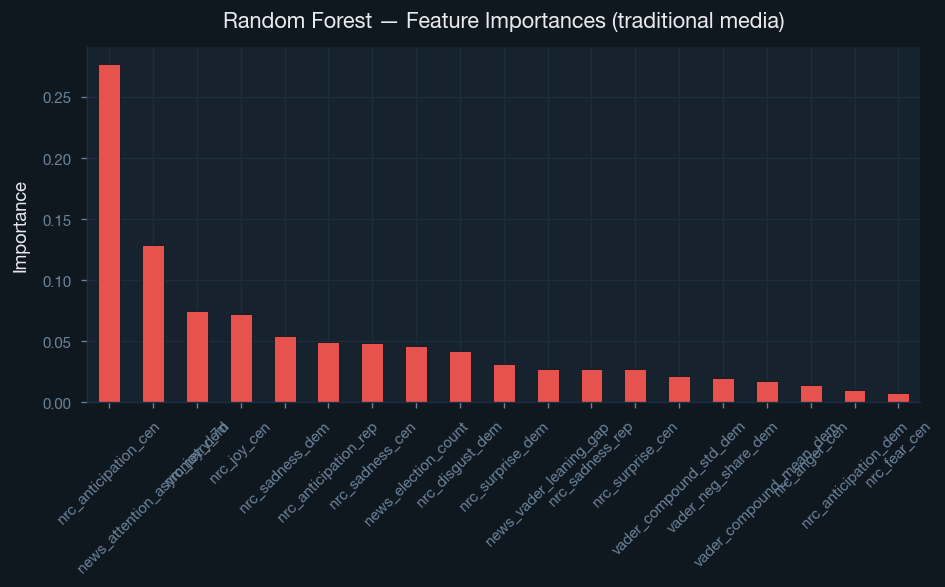

In [8]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=TRAD_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
fi.plot(kind="bar", ax=ax, color=PALETTE[1], edgecolor=BG_DARK)
ax.set_title("Random Forest — Feature Importances (traditional media)", color=TEXT_PRIMARY, fontweight="bold")
ax.set_ylabel("Importance", color=TEXT_PRIMARY)
ax.tick_params(colors=TEXT_MUTED, axis="x", labelrotation=45)
ax.tick_params(colors=TEXT_MUTED, axis="y")
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
plt.tight_layout()
plt.show()

## 7. Model 3 — Support Vector Regression (tuned kernel)

SVR finds a regression function within an ε-tube. Kernel is tuned over linear, rbf, poly, sigmoid.

In [9]:
def make_svr(kernel, C, epsilon):
    return SVR(kernel=kernel, C=C, epsilon=epsilon, gamma="scale")

svr_param_grid = {
    "kernel" : ["linear", "rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-10 configurations (sorted by CV MAE):")
print(svr_tune_df.head(10).to_string(index=False))

svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM — Hyperparameter Tuning ===
  Best params : {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.05}

  Top-10 configurations (sorted by CV MAE):
 kernel     C  epsilon   cv_mae  cv_mae_std
 linear   0.1     0.05 0.011464    0.003529
 linear   1.0     0.05 0.011464    0.003529
 linear 100.0     0.05 0.011464    0.003529
 linear  10.0     0.05 0.011464    0.003529
    rbf   0.1     0.01 0.012013    0.001534
sigmoid 100.0     0.05 0.012026    0.003222
sigmoid  10.0     0.05 0.012026    0.003222
sigmoid   1.0     0.05 0.012026    0.003222
sigmoid   0.1     0.05 0.012026    0.003222
    rbf  10.0     0.05 0.012033    0.002259

=== SVM — CV (best params) ===
  Fold 1: MAE=0.0161  RMSE=0.0198  DA=0.407  R2=-0.7221
  Fold 2: MAE=0.0075  RMSE=0.0104  DA=0.630  R2=-0.1254
  Fold 3: MAE=0.0108  RMSE=0.0141  DA=0.630  R2=0.0301
  -- Mean --  MAE=0.0115  RMSE=0.0148  DA=0.556  R2=-0.2724


,MAE,RMSE,Dir. Accuracy,R2
1,0.0161,0.0198,0.4074,-0.7221
2,0.0075,0.0104,0.6296,-0.1254
3,0.0108,0.0141,0.6296,0.0301
Mean,0.0115,0.0148,0.5556,-0.2724
Std,0.0043,0.0047,0.1283,0.3971


In [10]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("SVM — Test set:")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM — Test set:
  MAE: 0.0169
  RMSE: 0.0222
  Dir. Accuracy: 0.5000
  R2: -0.2073


## 8. Model 4 — XGBoost Regressor

XGBoost builds trees sequentially, each fitting the residual of the previous ensemble. We tune `max_depth`, `learning_rate`, and `n_estimators`.

In [11]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': 4, 'learning_rate': 0.01, 'n_estimators': 100}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         4           0.01           100 0.011230    0.002338
         3           0.01           100 0.011230    0.002367
         2           0.01           100 0.011335    0.002197
         4           0.01           200 0.011620    0.002659
         3           0.01           200 0.011717    0.002703

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0132  RMSE=0.0171  DA=0.444  R2=-0.2914
  Fold 2: MAE=0.0080  RMSE=0.0098  DA=0.556  R2=0.0106
  Fold 3: MAE=0.0125  RMSE=0.0169  DA=0.444  R2=-0.3922
  -- Mean --  MAE=0.0112  RMSE=0.0146  DA=0.481  R2=-0.2244


,MAE,RMSE,Dir. Accuracy,R2
1,0.0132,0.0171,0.4444,-0.2914
2,0.0080,0.0098,0.5556,0.0106
3,0.0125,0.0169,0.4444,-0.3922
Mean,0.0112,0.0146,0.4815,-0.2244
Std,0.0029,0.0042,0.0642,0.2096


In [12]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

XGBoost — Test set:
  MAE: 0.0163
  RMSE: 0.0216
  Dir. Accuracy: 0.5000
  R2: -0.1429


## 9. Naive Baseline — Always Predict Zero

The naive model always predicts `Δprob = 0`. Any model should beat this.

In [13]:
print("=== Naive (zero) — CV ===")
naive_records = []
for i, (train_idx, val_idx) in enumerate(folds, 1):
    y_val  = y_tv[val_idx]
    y_zero = np.zeros_like(y_val)
    m = {"Fold": i, **compute_metrics(y_val, y_zero)}
    naive_records.append(m)
    print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

naive_agg  = pd.DataFrame(naive_records).set_index("Fold")
naive_mean = naive_agg.mean().rename("Mean")
naive_std  = naive_agg.std().rename("Std")
naive_cv   = pd.concat([naive_agg, naive_mean.to_frame().T, naive_std.to_frame().T])
print(f"  -- Mean --  MAE={naive_mean['MAE']:.4f}  RMSE={naive_mean['RMSE']:.4f}  "
      f"DA={naive_mean['Dir. Accuracy']:.3f}  R2={naive_mean['R2']:.4f}")

naive_pred = np.zeros(len(y_test))
naive_test = compute_metrics(y_test, naive_pred)
print("\nNaive (zero) — Test set:")
for k, v in naive_test.items():
    print(f"  {k}: {v:.4f}")

naive_cv.round(4)

=== Naive (zero) — CV ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.000  R2=-0.0044
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.037  R2=-0.0013
  Fold 3: MAE=0.0111  RMSE=0.0155  DA=0.000  R2=-0.1700
  -- Mean --  MAE=0.0101  RMSE=0.0135  DA=0.012  R2=-0.0586

Naive (zero) — Test set:
  MAE: 0.0162
  RMSE: 0.0208
  Dir. Accuracy: 0.0000
  R2: -0.0570


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.0000,-0.0044
2,0.0076,0.0099,0.0370,-0.0013
3,0.0111,0.0155,0.0000,-0.1700
Mean,0.0101,0.0135,0.0123,-0.0586
Std,0.0022,0.0031,0.0214,0.0965


## 10. Model Comparison

CV performance (mean over 3 folds) and test-set performance for all models.

In [14]:
cv_summary = pd.DataFrame({
    "Naive (zero)"    : naive_cv.loc["Mean"],
    "Ridge Regression" : lr_cv.loc["Mean"],
    "Random Forest"   : rf_cv.loc["Mean"],
    "SVM"             : svm_cv.loc["Mean"],
    "XGBoost"         : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Naive (zero)"    : "— (always 0)",
    "Ridge Regression"  : f"alpha={ridge_best['alpha']}",
    "Random Forest"   : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM"             : f"k={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"         : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

CV performance (mean across 3 walk-forward folds):


,Best params,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),— (always 0),0.0101,0.0135,0.0123,-0.0586
Ridge Regression,alpha=1000.0,0.0103,0.0137,0.4568,-0.0981
Random Forest,"d=2, leaf=1",0.0113,0.0147,0.4691,-0.2436
SVM,"k=linear, C=0.1, ε=0.05",0.0115,0.0148,0.5556,-0.2724
XGBoost,"d=4, lr=0.01, n=100",0.0112,0.0146,0.4815,-0.2244


In [15]:
test_summary = pd.DataFrame({
    "Naive (zero)"    : naive_test,
    "Ridge Regression" : lr_test,
    "Random Forest"   : rf_test,
    "SVM"             : svm_test,
    "XGBoost"         : xgb_test,
}).T.round(4)

print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),0.0162,0.0208,0.0,-0.0570
Ridge Regression,0.0160,0.0208,0.5,-0.0645
Random Forest,0.0164,0.0215,0.5,-0.1357
SVM,0.0169,0.0222,0.5,-0.2073
XGBoost,0.0163,0.0216,0.5,-0.1429


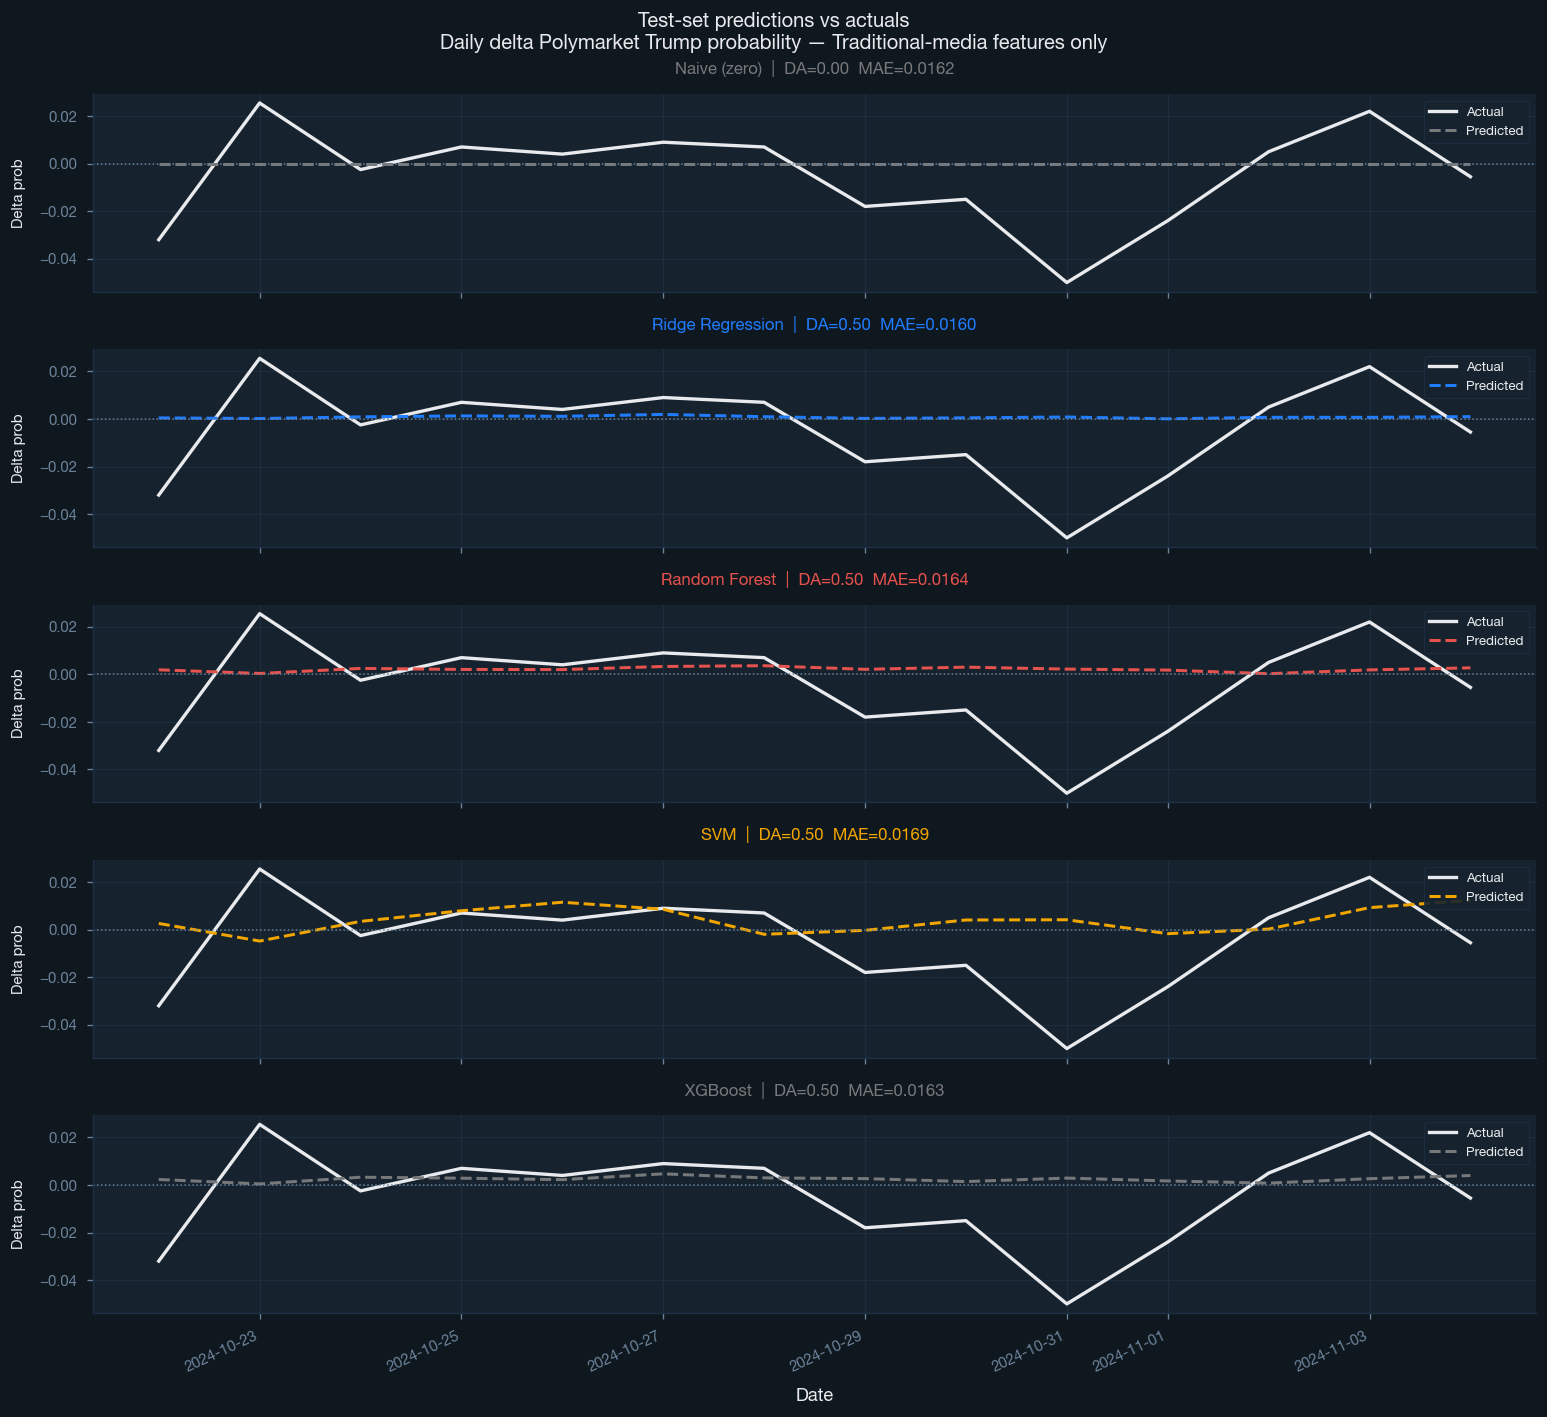

In [16]:
test_dates = df_test["date"].values
preds_list = [
    ("Naive (zero)",     naive_pred),
    ("Ridge Regression",  lr_pred),
    ("Random Forest",    rf_pred),
    ("SVM",              svm_pred),
    ("XGBoost",          xgb_pred),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — Traditional-media features only",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

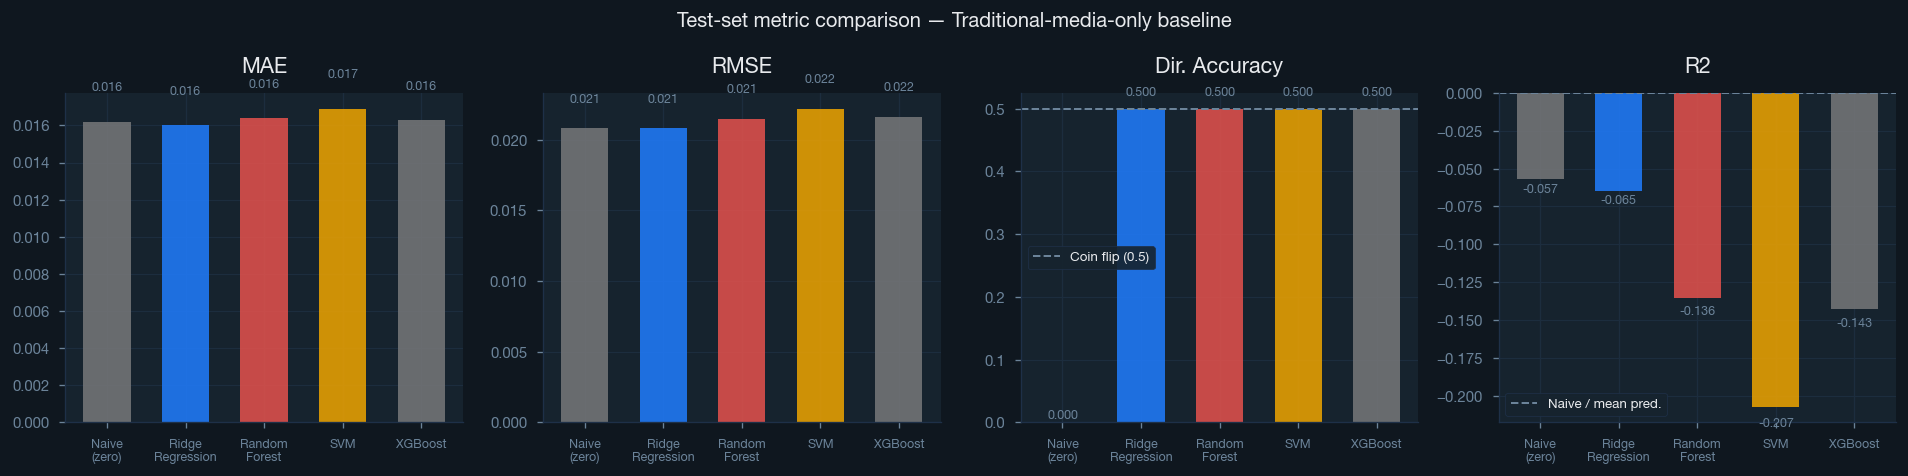

In [17]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Coin flip (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Naive / mean pred.")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=7.5, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=7.5, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Traditional-media-only baseline",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path

# ── Export test-set results to CSV for model_analysis.ipynb ──────────────────
FEATURE_SET = "Traditional (19f)"
CSV_NAME    = "traditional_19f.csv"
OUT_DIR     = Path("../../4_model_analysis/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_export = test_summary.copy()
df_export.index.name = "Model"
df_export = df_export.reset_index()
df_export = df_export.rename(columns={"Dir. Accuracy": "DA"})
df_export["Model"] = df_export["Model"].replace({"Ridge Regression": "Ridge"})
df_export.insert(0, "Feature_set", FEATURE_SET)

out_path = OUT_DIR / CSV_NAME
df_export.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
display(df_export)

Results saved → ../../4_model_analysis/results/traditional_19f.csv


,Feature_set,Model,MAE,RMSE,DA,R2
0,Traditional (19f),Naive (zero),0.0162,0.0208,0.0,-0.0570
1,Traditional (19f),Ridge,0.0160,0.0208,0.5,-0.0645
2,Traditional (19f),Random Forest,0.0164,0.0215,0.5,-0.1357
3,Traditional (19f),SVM,0.0169,0.0222,0.5,-0.2073
4,Traditional (19f),XGBoost,0.0163,0.0216,0.5,-0.1429
